In [1]:
#from data import load_data
%load_ext autoreload
%autoreload 2
import numpy as np
import json
import os
import matplotlib.pyplot as plt

In [2]:
embeddings = np.load('logs/2026_6_26/2/embeddings.npy')
print(embeddings.shape)

(19391, 30)


Text(0.5, 1.0, 'Training loss')

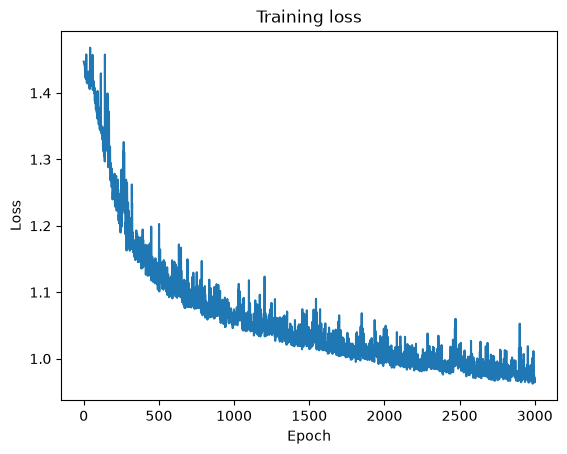

In [3]:
with open(os.path.join("logs/2026_6_26/2", 'metrics.json'), 'r') as f:
    results = json.load(f)

plt.plot(results['train_losses'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss')

Text(0, 0.5, 'MAP')

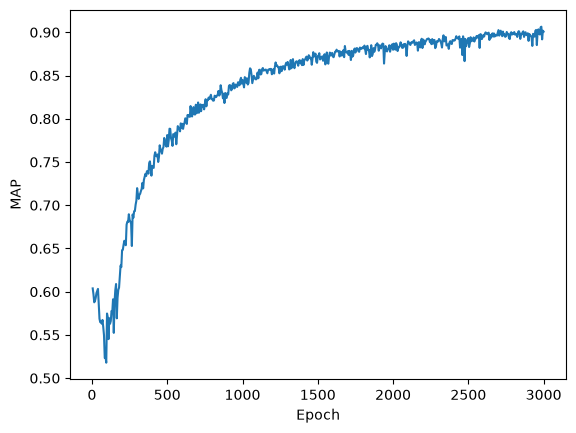

In [4]:
epochs = [m['epoch'] for m in results['val_metrics']]
maps = [m['ap'] for m in results['val_metrics']]  # ou 'ap' selon ce que retourne compute_metrics

plt.plot(epochs, maps)
plt.xlabel('Epoch')
plt.ylabel('MAP')

Text(0.5, 1.0, 'Distribution des normes dans B^n')

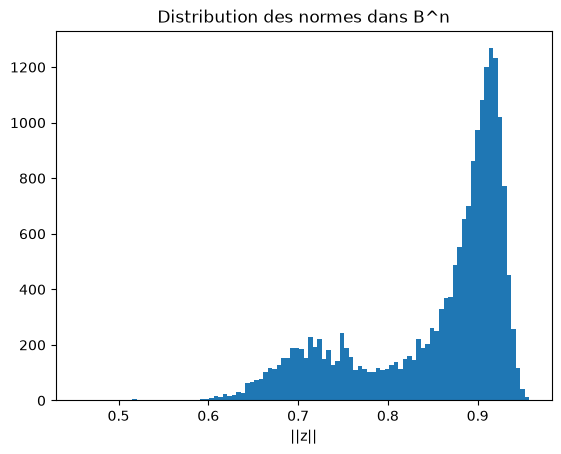

In [5]:
norms = np.linalg.norm(embeddings, axis=1)

plt.hist(norms, bins=100)
plt.xlabel('||z||')
plt.title('Distribution des normes dans B^n')

In [5]:
import OT
import poincare
from load_data import *

manifold = poincare.PoincareManifold()
nodes = list(G_hpo_work.nodes())
node2idx = {n: i for i, n in enumerate(nodes)}

#C = OT.compute_costs_matrix_wasserstein2(work_omim, work_orpha, node2idx, embeddings, manifold, c=1.)
gt_set, valid_omim, valid_orpha = OT.f_ground_truth(work_omim, work_orpha, df_orpha_omim_exact)

/home/onyxia/work/OT_simulation_maladies/HGCN/load_data.py:69: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  profils_omim = profils_omim.reset_index()


In [ ]:
# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = OT.compute_transport(C, a=None, b=None)
ranks, pairs = OT.evaluate_transport(ot_plan, gt_set, C)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C)
print(epsilon)
ot_plan_reg, ot_cots_reg = OT.compute_transport_sinkhorn(C, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = OT.evaluate_transport(ot_plan_reg, gt_set, C)

======== Sans régularisation ========
Paires évaluées : 2237
Top-1 accuracy : 0.374 (837/2237)
Top-3 accuracy : 0.409 (916/2237)
Top-5 accuracy : 0.411 (920/2237)
 Rang moyen: 951.68
======== Avec régularisation ========
0.11578572626100278
Paires évaluées : 2237
Top-1 accuracy : 0.397 (889/2237)
Top-3 accuracy : 0.515 (1152/2237)
Top-5 accuracy : 0.558 (1248/2237)
 Rang moyen: 86.30


In [ ]:
import data
import pandas as pd

all_diseases =pd.concat([work_omim, work_orpha], ignore_index=True)

w, _, _ = OT.compute_information_content(all_diseases, G_hpo_work)
ic = {k:-np.log(t) for k,t in w.items()}

C_ic = OT.compute_costs_matrix_wasserstein2(work_omim, work_orpha, node2idx, embeddings, manifold, c=1., weights=ic)

Precompute...
Finished !
Precomputing full HPO distance matrix...


Distance matrix rows: 100%|██████████| 42/42 [02:07<00:00,  3.03s/it]


HPO distance matrix: (10649, 10649)


OMIM:   0%|          | 0/6562 [00:00<?, ?it/s]

AssertionError: 
Arrays are not almost equal to 6 decimals a and b vector must have the same sum
 ACTUAL: np.float64(476.1811396018715)
 DESIRED: np.float64(312.67946602196315)

In [31]:
work_orpha[work_orpha['HP:0010523']==1]['database_id']

8671    ORPHA:100069
8672    ORPHA:100070
Name: database_id, dtype: str

In [6]:
df_orpha_omim[df_orpha_omim['orpha_id']=='ORPHA:100070']

,orpha_id,omim_id,mapping_type
8273,ORPHA:100070,OMIM:607485,NTBT (ORPHAcode is narrower than the targeted ...
8274,ORPHA:100070,OMIM:172700,NTBT (ORPHAcode is narrower than the targeted ...
8275,ORPHA:100070,OMIM:600274,NTBT (ORPHAcode is narrower than the targeted ...


In [29]:
work_omim[work_omim['database_id']=='OMIM:1163']

,database_id,HP:0000002,HP:0000003,HP:0000006,HP:0000007,HP:0000008,HP:0000009,HP:0000010,HP:0000011,HP:0000012,...,HP:6001352,HP:6001353,HP:6001360,HP:6001380,HP:6001410,HP:6001411,HP:6001425,HP:6001439,HP:6001440,HP:6001454


In [8]:
work_omim0 = work_omim[work_omim['database_id'].isin(valid_omim)]
work_orpha0 = work_orpha[work_orpha['database_id'].isin(valid_orpha)]
work_omim0 = work_omim0.reset_index(drop=True)
work_orpha0 = work_orpha0.reset_index(drop=True)
hpo_cols0 = [c for c in work_omim0.columns if c.startswith("HP:")]

# ground_truth s'appuie sur les indices des maladies dans les datasets initiaux
gt_set, valid_omim0, valid_orpha0 = OT.f_ground_truth(work_omim0, work_orpha0, df_orpha_omim_exact)
C0 = OT.compute_costs_matrix_wasserstein2(work_omim0, work_orpha0, node2idx, embeddings, manifold, c=1.)

Precompute...
Finished !
Precomputing full HPO distance matrix...


Distance matrix rows: 100%|██████████| 34/34 [00:15<00:00,  2.16it/s]


HPO distance matrix: (8684, 8684)


OMIM: 100%|██████████| 2237/2237 [03:56<00:00,  9.48it/s]


In [9]:
print("======== Sans régularisation ========")
ot_plan, ot_cost = OT.compute_transport(C0, a=None, b=None)
ranks, pairs = OT.evaluate_transport(ot_plan, gt_set, C0)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C0)
print(epsilon)
ot_plan_reg, ot_cots_reg = OT.compute_transport_sinkhorn(C0, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = OT.evaluate_transport(ot_plan_reg, gt_set, C0)

======== Sans régularisation ========
Paires évaluées : 2237
Top-1 accuracy : 0.446 (998/2237)
Top-3 accuracy : 0.447 (1000/2237)
Top-5 accuracy : 0.447 (1001/2237)
 Rang moyen: 613.15
======== Avec régularisation ========
0.11453635119644678
Paires évaluées : 2237
Top-1 accuracy : 0.437 (978/2237)
Top-3 accuracy : 0.561 (1254/2237)
Top-5 accuracy : 0.605 (1353/2237)
 Rang moyen: 51.34
